# 00 · Datos y features

Descarga el panel de mercado, construye los 20 canales causales de `X`, mide sobre ellos los hechos estilizados que ningún generador gaussiano puede reproducir y deja constancia firmada de con qué datos exactos se trabajó.

**Responsable:** Oscar

**Entradas**

- `data/catalog.yaml`

**Salidas**

- `data/raw/precios.parquet`
- `data/processed/canales.parquet`
- `data/processed/objetivos.parquet`
- `results/figures/muestra_efectiva.png`
- `results/figures/colas_y_agrupamiento.png`
- `results/figures/perfil_de_canales.png`

**Tiempo estimado:** ~5 min la primera vez (la descarga de yfinance domina); ~30 s con la caché ya escrita.

In [1]:
import sys; sys.path.insert(0, "..")   # permite ejecutar desde notebooks/
import src                              # fija el backend de Keras a PyTorch
from src import config, viz
config.fijar_semillas()
viz.aplicar_estilo()

In [2]:
import matplotlib.pyplot as plt

from src import datos, features, ventanas

# El catálogo se cachea por sesión. Sin esto, editar el YAML con el kernel vivo
# y lanzar un Run All regeneraría los canales con el catálogo antiguo, en
# silencio y sin que nada lo delatara.
config.cargar_catalogo.cache_clear()

## Procedencia: qué panel, exactamente

`data/catalog.yaml` es la fuente de verdad. Ningún ticker, fecha ni longitud de
ventana está escrito en este notebook ni en `src/features.py`: todo se lee del
catálogo, y desde esta versión eso incluye los ocho hiperparámetros de ventana
que antes estaban duplicados a mano. Cambiar un parámetro allí y reejecutar este
notebook y el 02 regenera el dataset completo.

yfinance no es una fuente inmutable: revisa su histórico y reajusta dividendos
hacia atrás, de modo que dos descargas separadas en el tiempo no dan lo mismo.
Por eso los precios se bajan una sola vez, quedan cacheados, y el notebook
imprime una **huella SHA-256 del contenido** —no del fichero, cuyos bytes cambian
con la versión de pyarrow— que identifica de forma reproducible con qué números
se trabajó. Si un compañero obtiene otras métricas, esa cadena dice en una línea
si el desacuerdo viene de los datos o del código.

Dos controles que **pueden fallar**, y esa es toda la diferencia con la tabla de
control anterior, que solo podía devolver "todo correcto" porque el panel ya
venía alineado antes de llegar a ella:

- **Contigüidad del índice.** El alineado recorta con `dropna(how="any")`, que
  puede abrir un agujero interior sin avisar. Las ventanas se construyen por
  posición, así que un agujero empalmaría dos tramos no contiguos dentro de la
  misma ventana de 60 días. Un hueco legítimo no es un error —el cierre de la
  NYSE por el huracán Sandy, el 29 y 30 de octubre de 2012, cae dentro del
  periodo y aparece en la tabla—, de modo que el criterio de alarma no es que la
  tabla esté vacía sino que ningún salto pase de la decena de días naturales.
- **Correspondencia caché-catálogo.** `descargar_precios` valida que las columnas
  del panel cacheado sean exactamente el universo declarado. Sin esa
  comprobación, añadir un ticker al catálogo no tendría ningún efecto visible.

Sobre el arranque del periodo: la tabla de cobertura ordena el universo por fecha
de origen y las tres primeras filas son TLT, IEF y LQD (2002-07-30). Son ellas
las que impiden ir más atrás. El arranque observado, en cambio, lo fija
`periodo.inicio` = 2003-01-02, que es una decisión del catálogo tomada a la vista
de esa disponibilidad. Decir que "el recorte lo gobiernan los ETF de renta fija"
sería falso: gobiernan el suelo, no el corte.

In [3]:
precios = datos.descargar_precios()
saltos = datos.huecos(precios.index)

print("Panel:", precios.shape, "·", precios.index[0].date(), "a", precios.index[-1].date())
print("Huella SHA-256 del contenido:", datos.huella(precios))
print("Ausentes:", int(precios.isna().sum().sum()), "· saltos de más de 4 días naturales:", len(saltos))
assert saltos.empty or int(saltos["dias"].max()) <= 10, "Hueco interior sospechoso en el índice."

print(datos.cobertura(precios).head(3).to_string())
saltos

Panel: (5940, 15) · 2003-01-02 a 2026-08-14
Huella SHA-256 del contenido: cc2dce500e0d
Ausentes: 0 · saltos de más de 4 días naturales: 2
           ticker         rol desde_fuente inicio_panel  limita_arranque
nombre                                                                  
tesoro_20y    TLT  renta_fija   2002-07-30   2003-01-02             True
tesoro_10y    IEF  renta_fija   2002-07-30   2003-01-02             True
credito_ig    LQD  renta_fija   2002-07-30   2003-01-02             True


,desde,hasta,dias
0,2006-12-29,2007-01-03,5
1,2012-10-26,2012-10-31,5


## Veinte canales causales sobre 69 bloques independientes

Todas las transformaciones son **causales**: el valor en `t` solo usa información
de `t` o anterior. El error clásico en series financieras es el z-score sobre la
muestra completa, que mejora las métricas porque el modelo conoce la media y la
desviación de todo el histórico, futuro incluido.

El contraste aplica cada transformación a la serie completa y a un prefijo de esa
misma serie, y exige que los valores del prefijo no cambien. Si la transformación
usara estadísticos del futuro, conocerlo reescribiría retroactivamente el pasado
y la discrepancia sería del orden de la unidad. Cubre **los veinte canales, no
siete**: cada transformación recibe el sub-panel de sus propias fuentes, de modo
que truncar filas trunca todas las fuentes en el mismo instante. Esa es la
semántica que las versiones anteriores emulaban a mano y solo para las
transformaciones de una sola serie, y por eso los dos z-scores de spread de
crédito y de pendiente de curva —justamente los que más se parecen al error
clásico— se quedaban fuera.

Se contrastan **dos** formas de mirar al futuro, porque una sola no basta. Una
transformación que **reescribe** el pasado —el z-score global— cambia los valores
del prefijo, y eso lo mide la columna `discrepancia`. Una que solo lo **desplaza**
—un `shift(-1)`, una media centrada— no cambia ningún valor interior y pasaría
inadvertida; lo que la delata es que el prefijo se queda sin poder rellenar sus
últimas posiciones, y eso lo cuenta la columna `huerfanas`. Un canal es causal
solo si las dos son cero.

La función además **reconstruye los veinte canales por su cuenta y comprueba que
su reconstrucción coincide exactamente con la de `construir_canales`**. Son dos
implementaciones independientes cuya coincidencia se asserta: si alguien cambia
una de las dos definiciones y no la otra, esto falla de forma ruidosa.

El orden de las columnas es un contrato con `data/processed/`: reordenarlo
invalida los generadores ya entrenados.

**Cuánta muestra hay de verdad.** El dataset tendrá 5.588 ventanas, pero dos
ventanas consecutivas comparten 59 de sus 60 días. Bloques que no comparten ni
una sesión hay **69**, un factor de inflación de 81×. Y de episodios de estrés
independientes hay **11** —rachas de `vix_nivel_z > 2` separadas por menos de 63
sesiones cuentan como uno—, de los que solo **tres** acumulan más de un mes de
mercado en estrés: 2007, 2008 y el COVID.

Ese 11 depende de dos grados de libertad y hay que declarar los dos. Por la regla
de fusión: 63 sesiones dan 11 episodios, 42 dan 13 y 21 dan 17; se adopta 63 —tres
veces el horizonte de predicción— por ser la más conservadora, la que hace parecer
más pequeña nuestra propia muestra. Y por el umbral, que pesa más: con
`vix_nivel_z > 1,5` salen 13 episodios y con `> 2,5` solo 5.

**Pero el número que de verdad limita el trabajo es menor todavía**, y es el que
imprime la celda siguiente: los generadores se ajustan solo con train, así que lo
que pueden aprender sobre crisis son los episodios de train, y de esos solo dos
—2007 y 2008— pasan de un mes de mercado en estrés. El COVID cae en validación y
ningún generador lo verá nunca. No nos faltan filas: nos faltan crisis, y ninguna
técnica de generación crea información sobre crisis que no ocurrieron.

Consecuencia operativa, y es la razón por la que estos números van aquí y no en
una nota al pie: cualquier intervalo de confianza calculado sobre las 5.588
ventanas es unas ochenta veces más estrecho de lo que debería.

Canales: (5668, 20) · contraste causal superado: 20 de 20
Episodios: 11 · en train: 7 · en train de más de un mes: 2
sesiones              5668.0
ventanas_nominales    5588.0
bloques_disjuntos       69.0
factor_inflacion        81.0


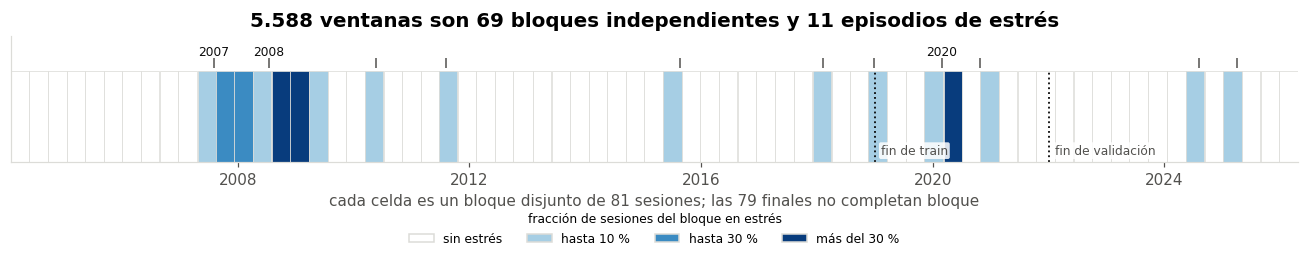

In [4]:
canales = features.construir_canales(precios)
causalidad = features.contraste_causalidad(precios)
efectivo = ventanas.tamano_muestral_efectivo(canales.index, config.ventanas())
episodios = features.episodios_estres(canales["vix_nivel_z"])

en_train = episodios[episodios["inicio"] <= config.particiones().train_hasta]
print("Canales:", canales.shape, "· contraste causal superado:", int(causalidad["causal"].sum()), "de", len(causalidad))
print("Episodios:", len(episodios), "· en train:", len(en_train), "· en train de más de un mes:", int((en_train["sesiones_estres"] > config.ventanas().horizonte).sum()))
print(efectivo.to_string())

fig, eje = plt.subplots(figsize=(12, 2.8))
viz.carril_bloques(canales["vix_nivel_z"] > 2, episodios, config.ventanas(), config.particiones(), eje=eje)
viz.guardar(fig, "muestra_efectiva")

## Hechos estilizados: la refutación del gaussiano, escrita antes de ejecutarlo

Esta sección caracteriza los datos **reales**. Es la referencia contra la que el
notebook 14 juzgará a cada generador, y es lo único de todo el trabajo que
*predice* el resultado de los notebooks 05 y 09 antes de ejecutarlos.

De los once hechos estilizados de Cont (2001), el panel permite contrastar ocho.
Quedan fuera por falta de datos, no por conveniencia: la intermitencia y la
asimetría entre escalas temporales exigen alta frecuencia, y la relación
volumen-volatilidad exige volumen, que este panel no tiene. De los ocho que
entran, los ocho tienen fila en la tabla, pero dos se comentan aquí porque
ninguno discrimina por sí solo: la **ausencia de autocorrelación lineal en los
retornos** —la ACF en el retardo 1 es −0,117, no cero, así que el criterio para un
generador debe ser reproducir la magnitud y no exigir cero— y la **asimetría
negativa**, que aplica a índices y no tendría sentido exigir en los veinte canales.

**Los canales de la tabla acotan el rango sectorial, no se eligen por quedar
bien**: al S&P 500 se añaden el sector financiero (curtosis máxima del panel,
20,6), el consumo cíclico (la mínima **entre los sectores**, 11,2) y la energía
(asimetría más negativa, −0,71). El mínimo absoluto del panel no es ninguno de
ellos sino `ret_dolar`, con 4,95, que se deja fuera por no ser renta variable: los
hechos estilizados de Cont se enuncian sobre acciones e índices, y una divisa no
tiene por qué cumplirlos.

**Las dos hipótesis falsables del trabajo.**

**Contra qué se contrasta, y por qué no vale la columna obvia.** La tentación es
enunciar la hipótesis contra la columna `gaussiano`, que es una única normal: da
curtosis exactamente 3 y, por el teorema de Isserlis, agrupamiento exactamente
cero. Pero **ese no es el generador que este repositorio implementa**. La decisión
D10 ajusta un modelo gaussiano independiente **por régimen**, así que el régimen
es constante dentro de cada ventana y lo que sale es una mezcla de escala. Una
mezcla sí tiene colas gruesas y, bajo el protocolo de autocorrelación agrupada, sí
tiene agrupamiento: la columna `mezcla` de la tabla da curtosis del orden de 8 y
ACF de |r| en torno a 0,3, muy cerca del valor real. Enunciar la hipótesis contra
la columna `gaussiano` sería predecir el fracaso de un objeto que nadie ha
escrito, y el notebook 05 nos refutaría a nosotros mismos.

**La hipótesis se enuncia por tanto sobre las colas condicionales**, que es la
única fila que ninguno de los cuatro procesos de referencia consigue reproducir.

- **H1 · Colas condicionales.** Tras dividir cada retorno por la volatilidad
  realizada de las 21 sesiones anteriores —causal, sin mirar al futuro—, la
  curtosis de los residuos de `ret_sp500` sigue siendo 7,29, con banda bootstrap
  al 95 % de [5,7 – 11,2]. Es decir: el agrupamiento de volatilidad explica parte
  de las colas, pero **no todas**. Ninguno de los cuatro procesos de referencia
  entra en esa banda: los tres de familia gaussiana se quedan entre 3,2 y 3,4, y
  la `t4` se pasa hasta 12,4 porque sus colas incondicionales son tan gruesas que
  sobreviven a la estandarización. Se considera refutada la predicción si un
  generador gaussiano —único o por régimen— entra en la banda.
- **H2 · Colas marginales.** La curtosis de `ret_sp500` es 16,47, banda
  [7,3 – 21,5]. Una gaussiana **única** predice exactamente 3,0. Se considera
  refutada si supera 4,0. Este criterio aplica solo al generador incondicional; la
  variante por régimen lo pasará, y eso es información, no un fallo.

La primera no es un error de ajuste que más datos o más épocas corrijan: para
generar colas condicionales hace falta que el modelo aprenda algo más que una
covarianza por régimen, y ese es el argumento a favor de los generadores
neuronales.

**H3 · Corolario, para no sacar la conclusión fácil.** El generador por jitter *sí*
pasará las dos, porque perturba muestras reales y hereda sus colas y su memoria.
Superarlas es por tanto necesario y no suficiente: lo que separa fidelidad de
información nueva es el contraste de memorización del notebook 14.

**Por qué hay bandas y no números sueltos.** La banda es un bootstrap por bloques
móviles de 250 sesiones, 300 réplicas, y cuesta unos cinco segundos. Remuestrear
observación a observación destruiría el agrupamiento de volatilidad, que es justo
lo que se mide, y devolvería bandas artificialmente estrechas. La banda convierte
"nuestro número" en "nuestro número ± error muestral", que es la diferencia entre
un dato y una afirmación.

**Una desviación deliberada de la metodología del proyecto, dicha en voz alta.**
La documentación prescribe reportar `beta_acf_abs`, el exponente del ajuste
log-log del decaimiento de la ACF de |r|. Aquí se calcula —la función lo devuelve
y los notebooks 05, 09 y 14 lo usarán— pero **se elimina de la tabla con un `drop`
explícito**: su banda bootstrap medida es [0,35 – 1,20], una anchura que lo hace
inservible como criterio, porque el ajuste log-log degenera cuando la ACF cruza
cero. En su lugar se reporta la ACF cruda en los retardos 1, 10 y 40, cuyas
bandas son estrechas y excluyen el cero. El retardo 100 aparece en la figura pero
no como criterio: sigue por encima de la banda i.i.d. (0,083 frente a ±0,026),
pero su banda bootstrap incluye el cero, y afirmar más de eso sería afirmar más
de lo que el dato sostiene.

**Cómo se lee la tabla.** Cada proceso de referencia reproduce una propiedad del
mercado y falla en otra, y **ninguno las reproduce todas**. El `gaussiano` falla en
colas (3,0) y en memoria (−0,01). La `t4` recupera las colas y sigue dando memoria
cero: las colas gruesas por sí solas no generan agrupamiento. El `garch11` recupera
la memoria (0,24) pero sus residuos estandarizados vuelven a ser gaussianos. Y la
`mezcla` —la que de verdad produce nuestro generador— recupera colas **y**
memoria a la vez, y aun así sus residuos son gaussianos. Esa última fila,
`curtosis_residuos`, es la única en la que los cuatro caen fuera de la banda real,
y por eso es la que sostiene H1.

**Cautela obligatoria.** La curtosis cae de 16,47 a 14,65 al eliminar una sola
observación, la del 16 de marzo de 2020. Se reporta, pero **no se usa como
criterio de aceptación** de ningún generador.

**Protocolo para los notebooks 05, 09 y 14.** La ACF de |r| de las muestras
sintéticas se calcula **agrupada** sobre todos los pares de todas las ventanas,
nunca ventana a ventana promediando después: con 60 puntos ese estimador está
sesgado hacia cero: sobre estos mismos datos reales devuelve 0,018 frente a los
0,313 del estimador agrupado, lo que bastaría para dar por bueno a un generador
sin ninguna memoria. Esto corrige la prescripción de
`docs/metodologia/metricas_calidad_sintetica.md`, que pide promediar sobre
ventanas.

,sp500,financiero,consumo_cic,energia,banda_inf,banda_sup,gaussiano,t4,garch11,mezcla
curtosis,16.468,20.558,11.210,16.085,7.261,21.463,2.983,11.112,7.483,8.026
curtosis_h21,7.185,10.363,5.582,9.146,3.785,22.778,2.704,3.187,5.533,7.156
curtosis_residuos,7.290,6.153,5.091,5.265,5.683,11.217,3.354,12.426,3.199,3.447
asimetria,-0.476,-0.208,-0.471,-0.714,-0.829,-0.154,0.006,0.104,-0.025,0.140
ac1_retorno,-0.117,-0.110,-0.047,-0.053,-0.187,-0.040,-0.007,0.010,0.014,0.010
ac1_absoluto,0.313,0.429,0.268,0.258,0.165,0.406,-0.009,0.002,0.243,0.310
ac10_absoluto,0.307,0.370,0.256,0.269,0.161,0.356,0.002,0.003,0.226,0.257
ac40_absoluto,0.160,0.321,0.181,0.142,0.057,0.196,0.014,0.005,0.167,0.097
ac100_absoluto,0.083,0.198,0.109,0.082,-0.018,0.113,-0.002,-0.005,0.082,-0.007
apalancamiento,-0.099,-0.068,-0.054,-0.112,-0.128,-0.063,0.001,-0.010,0.012,0.013


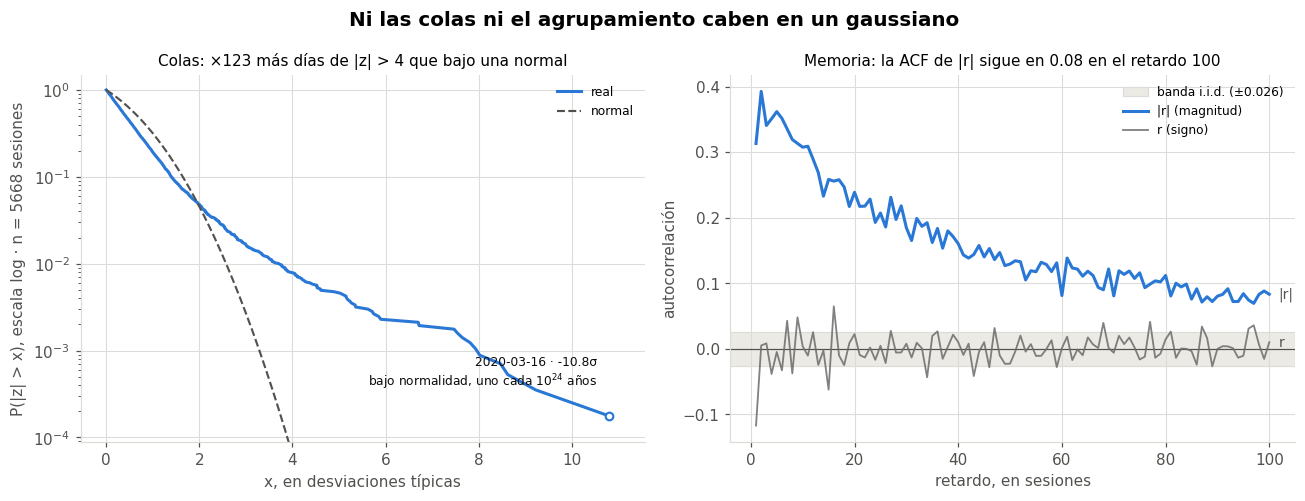

In [5]:
r = canales["ret_sp500"]
extremos = ["ret_sp500", "ret_sector_financiero", "ret_sector_consumo_cic", "ret_sector_energia"]
tabla = (features.hechos_estilizados(canales[extremos])
         .drop(index="beta_acf_abs")   # banda medida [0,35 - 1,20]: inservible, ver arriba
         .rename(columns=lambda c: c.replace("ret_sector_", "").replace("ret_", ""))
         .join(features.banda_bootstrap(r)).join(features.calibracion_hechos()))

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.6))
viz.supervivencia_colas(r, eje=ejes[0])
viz.autocorrelacion_absolutos(r, eje=ejes[1])
fig.suptitle("Ni las colas ni el agrupamiento caben en un gaussiano", fontsize=13, fontweight="bold")
viz.guardar(fig, "colas_y_agrupamiento")

tabla.round(3)

## Escala y señal: qué aporta cada canal

Dos afirmaciones sobre las mismas veinte filas, ordenadas igual para que se lean
a la vez.

**Las escalas difieren en dos órdenes de magnitud.** El canal más disperso,
`vix_cambio`, tiene 411 veces la desviación típica del menos disperso,
`dispersion_sectorial`. Un modelo entrenado sin escalar por canal optimizaría el
primero e ignoraría el resto. Es la justificación cuantitativa del escalado por
canal del notebook 02, y de que ese escalador se ajuste solo con train.

**La señal de régimen está concentrada en las derivadas.** El AUC univariante mide
cuánto discrimina cada canal, usado como único predictor, entre "el próximo mes
estará en el decil superior de volatilidad" y el resto. Seis canales superan 0,70
y todos son derivados; ningún retorno pasa de 0,55. Es la justificación de por qué
el panel no es un panel de retornos: sin las derivadas, la tarea de régimen no
tendría de dónde agarrarse.

**Protocolo del AUC, y las tres cosas que hay que declarar.**

1. Se calcula **solo sobre el tramo de entrenamiento** (hasta 2018-12-31, 3.753
   ventanas y 376 positivas), porque es el único donde a un modelo le está
   permitido mirar. La cifra restringida resulta ser *mejor* que la del histórico
   completo —`vix_nivel_z` pasa de 0,890 a 0,905— y conviene decirlo antes de que
   lo pregunten: no se ha elegido el tramo que favorece, se ha elegido el tramo
   legítimo, y da la casualidad de que favorece.
2. Se reporta `max(AUC, 1-AUC)`, porque el signo de un canal es arbitrario. Esa
   simetrización es levemente optimista: un canal de puro ruido no da 0,50 exacto
   sino algo por encima. Por eso el umbral de lectura es 0,70 y no 0,52.
3. **El AUC va sin banda, y eso hay que decirlo.** A los hechos estilizados se les
   exige banda bootstrap y a `beta_acf_abs` se le retira la fila por tenerla
   demasiado ancha; sería incoherente presentar aquí seis cifras a tres decimales
   como si fueran exactas. Aplicando el mismo bootstrap por bloques, la banda de
   estos AUC ronda ±0,15, de modo que la lectura defendible no es el orden entre
   canales vecinos sino la separación entre los dos bloques: las derivadas de
   cabeza están muy por encima de 0,70 y ningún retorno se despega de 0,55. Por la
   misma razón, que `spread_credito_z` pase de 0,744 sobre el histórico completo a
   0,865 sobre train es compatible con el ruido muestral y no se presenta como un
   hallazgo.

Las dos excepciones visibles en la figura son información, no defecto:
`vix_cambio` y `pendiente_curva_z` son derivadas y se quedan en 0,50, y
`dispersion_sectorial` es una derivada con la escala más pequeña del panel. Que el
color codifique la familia y no el valor es lo que las hace visibles.

**Esta figura repara un agujero documental.** La metodología del proyecto cita hoy
un AUC de 0,80 para un canal `MOVE_level_z` que **no existe en este catálogo**: es
una cifra heredada de otro panel. Aquí queda sustituida por una medida sobre estos
datos.

**Y un dato que justifica condicionar por régimen.** La correlación media entre los
nueve retornos sectoriales pasa de 0,615 en calma a 0,786 en estrés, medida sobre
el mismo tramo de train y con el estrés definido exactamente igual que el proxy
del AUC —decil superior de `vol_futura`—, para que los dos números sean
comparables entre sí. En crisis el panel deja de tener nueve sectores y pasa a
tener casi uno.

La cautela que acompaña al dato: un modelo de un solo factor con cargas constantes
y la volatilidad del factor duplicada en estrés reproduce un salto de este tamaño
**sin ningún cambio en la estructura de dependencia**. El número, por tanto, no
demuestra por sí solo que la correlación cambie; demuestra que un generador
incondicional tendría que reproducir a la vez dos regímenes de escala muy
distintos con una sola matriz de covarianza. Esa es la justificación de condicionar,
y es más modesta que la lectura fácil.

AUC sobre train · 3753 ventanas, 376 positivas · canales por encima de 0,70: 6
Correlación media entre retornos sectoriales · calma 0.615 · estrés 0.786


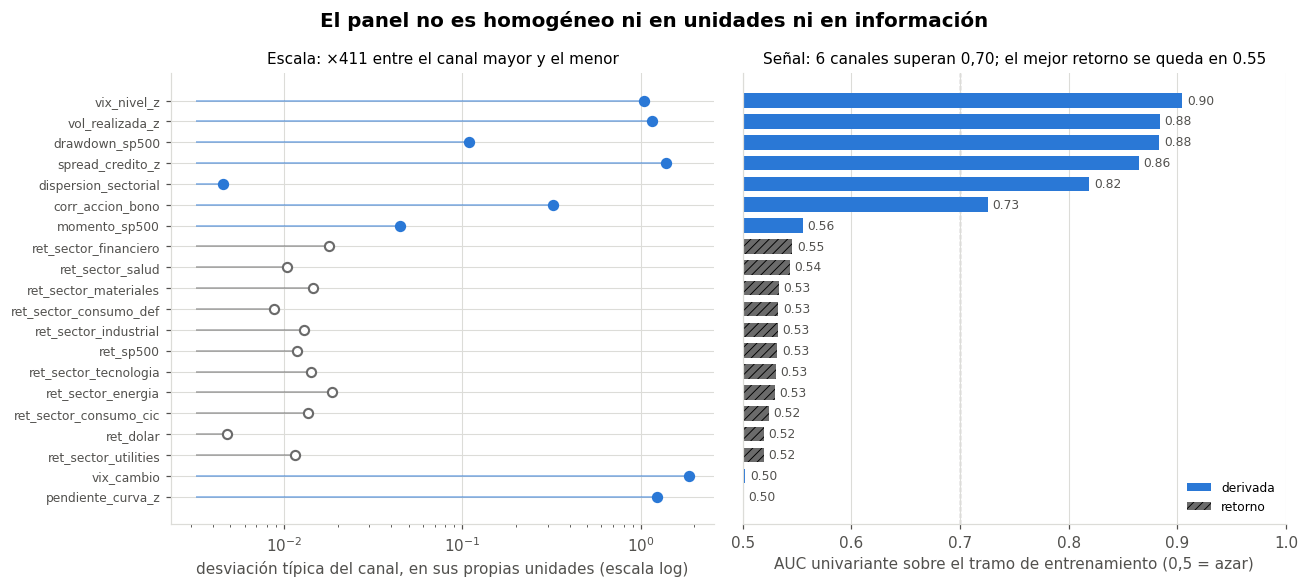

In [6]:
objetivos = features.objetivos(precios, config.ventanas().horizonte)
familias = config.familias_canales()
auc = features.auc_univariante(canales, objetivos["vol_futura"], hasta=config.particiones().train_hasta)
correlacion = features.correlacion_media(canales, objetivos["vol_futura"], hasta=config.particiones().train_hasta)

print("AUC sobre train ·", int(auc["n"].iloc[0]), "ventanas,", int(auc["positivos"].iloc[0]), "positivas · canales por encima de 0,70:", int((auc["auc"] > 0.70).sum()))
print("Correlación media entre retornos sectoriales · calma", round(correlacion["calma"], 3), "· estrés", round(correlacion["estres"], 3))

fig, ejes = plt.subplots(1, 2, figsize=(12, 5.4), sharey=True)
viz.puntos_escala(canales.std().reindex(auc.index), familias, eje=ejes[0])
viz.barras_auc(auc["auc"], familias, eje=ejes[1]); ejes[1].tick_params(axis="y", length=0)
fig.suptitle("El panel no es homogéneo ni en unidades ni en información", fontsize=13, fontweight="bold")
viz.guardar(fig, "perfil_de_canales")

## Escritura

`canales` se escribe recortado, con 5.668 filas: las 272 primeras sesiones no
tienen valor en todos los canales porque el z-score causal necesita 252 sesiones
de historia antes de emitir el primero.

`objetivos` se escribe **completo**, con las 5.940 filas del panel de precios y no
solo con las que acabarán entrando en alguna ventana. El motivo es que el contrato
con el notebook 02 es el alineado por fecha: `construir_ventanas` reindexa los
objetivos sobre `canales.index` y descarta las posiciones cuyo objetivo es NaN.
Recortar aquí no cambiaría ni una ventana y sí rompería la simetría con
`precios.parquet`. Las 21 últimas filas son NaN por construcción: el horizonte
futuro se sale del histórico.

La huella de `canales` es la garantía de no regresión de este notebook: si una
modificación futura de `src/features.py` la cambia sin que nadie lo pretenda, se
ve en esta salida antes de que llegue a los generadores.

In [7]:
src.DIR_PROCESADO.mkdir(parents=True, exist_ok=True)

canales.to_parquet(src.DIR_PROCESADO / "canales.parquet")
objetivos.to_parquet(src.DIR_PROCESADO / "objetivos.parquet")

print("Canales:", canales.shape, "· huella", datos.huella(canales))
print("Objetivos:", objetivos.shape, "· filas anteriores a la primera ventana:", len(objetivos) - len(canales))

Canales: (5668, 20) · huella b6e355574687
Objetivos: (5940, 3) · filas anteriores a la primera ventana: 272


## Salidas generadas

In [8]:
from pathlib import Path

salidas = [
    src.DIR_CRUDO / "precios.parquet",
    src.DIR_PROCESADO / "canales.parquet",
    src.DIR_PROCESADO / "objetivos.parquet",
    src.DIR_FIGURAS / "muestra_efectiva.png",
    src.DIR_FIGURAS / "colas_y_agrupamiento.png",
    src.DIR_FIGURAS / "perfil_de_canales.png",
]

for ruta in salidas:
    ruta = Path(ruta)
    marca = "ok" if ruta.exists() else "--"
    print("[{}] {}".format(marca, ruta.relative_to(src.RAIZ)))

[ok] data\raw\precios.parquet
[ok] data\processed\canales.parquet
[ok] data\processed\objetivos.parquet
[ok] results\figures\muestra_efectiva.png
[ok] results\figures\colas_y_agrupamiento.png
[ok] results\figures\perfil_de_canales.png
